In [ ]:
# Imports

!pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer

# Core Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import QFTGate

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Tools
!git clone https://github.com/Wlitkopa/regev-quantum-algorithm.git
import sys
sys.path.append('/content/regev-quantum-algorithm')
# from gates.haner.modular_exponentiation import modular_exponentiation_gate as modEXP # Expected signature: modEXP(constant: int, N: int, n: int)


# Other imports
import numpy as np
import math
import matplotlib as mpl
from qiskit.quantum_info import Operator
from fractions import Fraction
from math import gcd, pi
from IPython.display import display
from google.colab import files

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.4 MB/s eta 0:00:00
  Created wh

In [ ]:
from typing import Tuple, List, Callable, Dict

Size = int
Name = str

QRegsSpec = Dict[Name, Size]

Value = int
Computation = Callable[[Value], Value]
ComputationsMap = Dict[Name, Computation]
ValuesMap = Dict[Name, Value]

del Tuple, List, Callable, Dict

In [ ]:
from itertools import chain

from qiskit.circuit import Gate

from gates.haner.constant_modulo_adder import double_controlled_constant_modulo_adder
from utils.circuit_creation import create_circuit
# from utils.typing_ import QRegsSpec


def controlled_constant_modulo_multiplier(constant: int, N: int, n: int) -> Gate:
    if n == 1:
        raise ValueError("Creating circuit for n = 1 not supported")

    circuit = create_circuit(controlled_constant_modulo_multiplier_regs(n), f'CC-Mult_({constant})_Mod_{N}')
    ctrl_qreg, x_qreg, y_qreg, flag_qreg = circuit.qregs

    for i in reversed(range(n)):
        partial_constant = (pow(2, i) * constant) % N

        g_qreg = x_qreg[:]
        g_qreg.pop(i)

        circuit.append(
            double_controlled_constant_modulo_adder(partial_constant, N, n),
            chain(ctrl_qreg, [x_qreg[i]], y_qreg, g_qreg, flag_qreg)
        )

    return circuit.to_gate()


def controlled_constant_modulo_multiplier_regs(n: int) -> QRegsSpec:
    if n == 1:
        raise ValueError("Case n = 1 not supported")

    return {
        'ctrl': 1,
        'x': n,
        'y': n,
        'flag': 1
    }

In [ ]:
from itertools import chain

from qiskit.circuit import Gate

# from gates.r_haner.constant_modulo_multiplier import controlled_constant_modulo_multiplier, \
#     controlled_constant_modulo_multiplier_regs
from utils.circuit_creation import create_circuit
# from utils.typing_ import QRegsSpec


def modular_exponentiation_gate(constant: int, N: int, n: int, qd: int) -> Gate:
    circuit = create_circuit(modular_exponentiation_gate_regs(n, qd), f'Exp({constant})_Mod_{N}')
    x_qreg, y_qreg, aux_qreg = circuit.qregs

    for i in range(qd):
        partial_constant = get_partial_constant(constant, i, N)
        circuit.append(

            controlled_modular_multiplication_gate(partial_constant, N, n),
            list(chain([x_qreg[i]], y_qreg, aux_qreg))
        )

    return circuit.to_gate()


def modular_exponentiation_gate_regs(n: int, qd: int) -> QRegsSpec:
    return {
        'x': qd,
        'y': n,
        'aux': n + 1
    }


def get_partial_constant(constant: int, i: int, N: int) -> int:
    return pow(constant, pow(2, i), mod=N)


def controlled_modular_multiplication_gate(constant, N, n) -> Gate:
    circuit = create_circuit(controlled_modular_multiplication_gate_regs(n), f'C-U({constant})_Mod_{N}')
    ctrl_qreg, x_qreg, aux_qreg, flag_qreg = circuit.qregs

    circuit.append(
        controlled_constant_modulo_multiplier(constant, N, n),
        chain.from_iterable(circuit.qregs)
    )

    for i in range(n):
        circuit.cswap(ctrl_qreg[0], x_qreg[i], aux_qreg[i])

    constant_inv = pow(constant, -1, mod=N)
    circuit.append(
        controlled_constant_modulo_multiplier(constant_inv, N, n).inverse(),
        chain.from_iterable(circuit.qregs)
    )

    return circuit.to_gate()


def controlled_modular_multiplication_gate_regs(n: int) -> QRegsSpec:
    spec = controlled_constant_modulo_multiplier_regs(n)
    return {(name if name != 'y' else 'aux'): size for (name, size) in spec.items()}

In [ ]:
def multidim_qft(d: int, n_per_reg: int) -> QuantumCircuit:
    # List of Sub-Registers that equate to the amount of dimentions in the d-QFT
    sub_registers = list()
    # sub_classical_registers = list()
    for reg in range(d):
        sub_registers.append(QuantumRegister(n_per_reg, name=f"reg_{reg}"))
    # the number of classical registers needed for all the qubits
    qc = QuantumCircuit(*sub_registers, name=f"QFT_{d}D")

    # Apply a 1D QFT to every qubit in the register, then repeat it for d registers
    for reg in range(d):
        start = reg * n_per_reg
        qubits = list(range(start, start + n_per_reg))
        qc.compose(QFTGate(num_qubits=n_per_reg), qubits=qubits, inplace=True)

    # Return the final quantum circuit for the d-QFT
    return qc

In [ ]:
@staticmethod
def is_prime(num):
    flag = True
    if num < 2:
        flag = False
    else:
        for i in range(2, num):
            if num % i == 0:
                flag = False
                break

    return flag

@staticmethod
def generate_a(d: int, N: int):
    a = []
    ind = 0
    num = 2
    while ind < d:
        if is_prime(num):
            if N % num == 0:
                print(f"We are very lucky! Here is p: {num} and q: {N//num}")
                num += 1
                continue
            a.append(int(math.pow(num, 2)))
            ind += 1
        num += 1
    return a

In [ ]:
!pip install qiskit qiskit-aer pylatexenc -q

In [ ]:
import qiskit
import qiskit_aer

print("Qiskit installed:", qiskit.__version__)
print("Qiskit Aer installed")

Qiskit installed: 2.5.0
Qiskit Aer installed


In [ ]:
# ============================================================
# Full input-driven Regev-style simulation pipeline
# This uses the modular_exponentiation_gate already defined earlier.
# ============================================================

import math
from math import gcd
from collections import Counter
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
from IPython.display import display


# ------------------------------------------------------------
# 1. Basic input validation
# ------------------------------------------------------------

def is_prime_basic(num: int) -> bool:
    """
    Simple primality test for small simulation inputs.
    Not meant for huge cryptographic numbers.
    """
    if num < 2:
        return False

    if num == 2:
        return True

    if num % 2 == 0:
        return False

    for k in range(3, int(math.sqrt(num)) + 1, 2):
        if num % k == 0:
            return False

    return True


def validate_factor_input(N: int):
    """
    Check whether N is a useful input for the factoring simulation.
    """
    if N <= 1:
        return {
            "valid": False,
            "reason": "N must be greater than 1.",
            "factor": None,
            "other": None
        }

    if N % 2 == 0:
        return {
            "valid": False,
            "reason": "N is even, so factoring is trivial.",
            "factor": 2,
            "other": N // 2
        }

    if is_prime_basic(N):
        return {
            "valid": False,
            "reason": "N is prime, so it has no nontrivial factors.",
            "factor": None,
            "other": None
        }

    return {
        "valid": True,
        "reason": "N is an odd composite number.",
        "factor": None,
        "other": None
    }


# ------------------------------------------------------------
# 2. Regev-style parameter selection
# ------------------------------------------------------------

def regev_parameters(N: int, mode: str = "cover_2n"):
    """
    Choose register sizes for the Regev-style simulation.

    n  = bit length of N
    d  = number of dimensions / number of x-registers
    nd = number of qubits per x-register

    mode = "cover_2n":
        choose nd so that d * nd is at least 2n.
        This gives Shor-like phase precision.

    mode = "notebook":
        uses the earlier heuristic floor(n/d + d).
    """
    n = N.bit_length()
    d = math.ceil(math.sqrt(n))

    if mode == "cover_2n":
        nd = math.ceil((2 * n) / d)

    elif mode == "notebook":
        nd = math.floor((n / d) + d)

    else:
        raise ValueError("mode must be either 'cover_2n' or 'notebook'.")

    M = 2 ** nd

    return {
        "N": N,
        "n": n,
        "d": d,
        "nd": nd,
        "M": M,
        "total_x_qubits": d * nd,
        "estimated_total_qubits": d * nd + n + (n + 1)
    }


# ------------------------------------------------------------
# 3. Generate Regev-style bases
# ------------------------------------------------------------

def generate_regev_bases(N: int, d: int):
    """
    Generate d coprime squared bases.

    Regev-style algorithms use several bases a_i.
    Here we choose prime squares: 2^2, 3^2, 5^2, ...
    but skip primes that divide N.

    If a prime divides N, we record that as a lucky factor.
    """
    bases = []
    lucky_factors = []

    candidate = 2

    while len(bases) < d:
        if is_prime_basic(candidate):
            g = gcd(candidate, N)

            if 1 < g < N:
                lucky_factors.append((g, N // g))
                candidate += 1
                continue

            # Use prime squared as the base.
            # The modular exponentiation code reduces it mod N internally.
            base = candidate ** 2

            if gcd(base, N) == 1:
                bases.append(base)

        candidate += 1

    return bases, lucky_factors


# ------------------------------------------------------------
# 4. Multi-dimensional QFT helper
# ------------------------------------------------------------

def build_multidim_qft_on_x(qc, x_registers, inverse: bool = True):
    """
    Apply a separate QFT or inverse QFT to each x-register.

    A d-dimensional QFT over a product register can be implemented as
    one QFT on each dimension/register.
    """
    nd = len(x_registers[0])

    if inverse:
        qft_gate = QFTGate(nd).inverse()
    else:
        qft_gate = QFTGate(nd)

    for xreg in x_registers:
        qc.append(qft_gate, list(xreg))

    return qc


# ------------------------------------------------------------
# 5. Full Regev-style circuit builder
# ------------------------------------------------------------

def build_regev_simulation_circuit(
    N: int,
    qd_mode: str = "cover_2n",
    inverse_qft: bool = True,
    measure: bool = True
):
    """
    Build the full Regev-style quantum sampling circuit.

    Circuit structure:

    1. Create d input x-registers.
    2. Create one shared y-register.
    3. Create one shared auxiliary register.
    4. Put every x-register into superposition.
    5. Initialize y = 1.
    6. Apply modular exponentiation for each dimension.
    7. Apply multi-dimensional inverse QFT.
    8. Measure the x-registers.
    """

    validation = validate_factor_input(N)

    if not validation["valid"]:
        print("Input shortcut:")
        print(validation)
        return None, validation

    params = regev_parameters(N, mode=qd_mode)

    n = params["n"]
    d = params["d"]
    nd = params["nd"]

    bases, lucky_factors = generate_regev_bases(N, d)

    # Create d input registers.
    x_registers = [
        QuantumRegister(nd, name=f"x{i+1}")
        for i in range(d)
    ]

    # Shared output and auxiliary registers.
    y_register = QuantumRegister(n, name="y")
    aux_register = QuantumRegister(n + 1, name="aux")

    # Classical register only stores x-register measurements.
    if measure:
        c_register = ClassicalRegister(d * nd, name="c")

        qc = QuantumCircuit(
            *x_registers,
            y_register,
            aux_register,
            c_register,
            name=f"Regev_N_{N}"
        )

    else:
        qc = QuantumCircuit(
            *x_registers,
            y_register,
            aux_register,
            name=f"Regev_N_{N}"
        )

    # Step 1: Put x-registers into superposition.
    for xreg in x_registers:
        qc.h(xreg)

    # Step 2: Initialize y = 1.
    qc.x(y_register[0])

    qc.barrier(label="modexp")

    # Step 3: Apply modular exponentiation for each dimension.
    for i in range(d):
        current_modexp_gate = modular_exponentiation_gate(
            bases[i],
            N,
            n,
            nd
        )

        qc.append(
            current_modexp_gate,
            list(x_registers[i]) + list(y_register) + list(aux_register)
        )

    qc.barrier(label="qft")

    # Step 4: Apply multi-dimensional inverse QFT.
    build_multidim_qft_on_x(
        qc,
        x_registers,
        inverse=inverse_qft
    )

    qc.barrier(label="measure")

    # Step 5: Measure only the x-registers.
    if measure:
        all_x_qubits = []

        for xreg in x_registers:
            all_x_qubits.extend(list(xreg))

        qc.measure(all_x_qubits, list(c_register))

    metadata = {
        **params,
        "bases": bases,
        "lucky_factors": lucky_factors,
        "inverse_qft": inverse_qft,
        "qd_mode": qd_mode
    }

    return qc, metadata


# ------------------------------------------------------------
# 6. Convert ugly Qiskit bitstrings into Regev measurement vectors
# ------------------------------------------------------------

def bitstring_to_regev_vector(bitstring: str, d: int, nd: int):
    """
    Convert a Qiskit measurement bitstring into a d-dimensional vector.

    Example output:
        (3, 7, 12)

    Qiskit displays classical bits big-endian, so we reverse first.
    """
    raw = bitstring.replace(" ", "")
    little_endian = raw[::-1]

    values = []

    for i in range(d):
        reg_bits_little = little_endian[i * nd : (i + 1) * nd]
        reg_value = int(reg_bits_little[::-1], 2)
        values.append(reg_value)

    return tuple(values)


def summarize_regev_counts(counts, d: int, nd: int, top: int = 15):
    """
    Convert raw count results into readable measurement vectors.
    """
    total = sum(counts.values())
    rows = []

    for bitstring, count in Counter(counts).most_common(top):
        vector = bitstring_to_regev_vector(bitstring, d, nd)

        rows.append({
            "measured_vector": vector,
            "count": count,
            "probability": count / total,
            "raw_bitstring": bitstring
        })

    return rows


# ------------------------------------------------------------
# 7. Run full simulation
# ------------------------------------------------------------

def run_regev_simulation(
    N: int,
    shots: int = 256,
    qd_mode: str = "cover_2n",
    inverse_qft: bool = True,
    optimization_level: int = 1,
    draw: bool = False
):
    """
    Build, transpile, simulate, and summarize the Regev-style circuit.
    """

    qc, metadata = build_regev_simulation_circuit(
        N=N,
        qd_mode=qd_mode,
        inverse_qft=inverse_qft,
        measure=True
    )

    if qc is None:
        return None, metadata, None, None

    print("=== Regev-style simulation metadata ===")
    for k, v in metadata.items():
        print(f"{k}: {v}")

    print("\nCircuit before transpilation:")
    print("qubits:", qc.num_qubits)
    print("depth:", qc.depth())
    print("ops:", qc.count_ops())

    simulator = AerSimulator()

    tqc = transpile(
        qc,
        simulator,
        optimization_level=optimization_level
    )

    print("\nCircuit after transpilation:")
    print("qubits:", tqc.num_qubits)
    print("depth:", tqc.depth())
    print("ops:", tqc.count_ops())

    print("\nRunning simulator...")
    result = simulator.run(tqc, shots=shots).result()
    counts = result.get_counts()

    summary = summarize_regev_counts(
        counts,
        d=metadata["d"],
        nd=metadata["nd"],
        top=15
    )

    print("\nTop measured Regev vectors:")
    for row in summary:
        print(row)

    if draw:
        display(qc.draw("mpl", fold=-1, plot_barriers=False))

    return qc, metadata, counts, summary


# ------------------------------------------------------------
# 8. Classical/lattice post-processing placeholder
# ------------------------------------------------------------

def lattice_postprocessing_placeholder(summary, metadata):
    """
    Placeholder for the classical Regev post-processing stage.

    The quantum circuit gives measurement vectors.
    In the full Regev algorithm, these vectors would be passed into
    a classical number-theoretic or lattice-based reconstruction routine.

    This project currently implements the quantum sampling stage and
    prepares the interface for the later lattice stage.
    """

    print("=== Classical post-processing placeholder ===")
    print("N:", metadata["N"])
    print("d:", metadata["d"])
    print("nd:", metadata["nd"])
    print("bases:", metadata["bases"])

    print("\nSample vectors available for post-processing:")

    for row in summary[:10]:
        print(row["measured_vector"], "probability:", row["probability"])

    print("\nNext step:")
    print("Use these vectors as input to a lattice/number-theoretic reconstruction routine.")


# ------------------------------------------------------------
# 9. Resource-only estimator
# ------------------------------------------------------------

def estimate_regev_resources(N_values):
    """
    Print parameter/resource estimates without trying to simulate huge circuits.
    """
    for test_N in N_values:
        print("\n==============================")
        print("N =", test_N)

        validation = validate_factor_input(test_N)
        print("validation:", validation)

        if validation["valid"]:
            params = regev_parameters(test_N)
            print("parameters:", params)

In [ ]:
# ============================================================
# Toy post-processing layer:
# turns measured Fourier samples into actual factors for small N
# ============================================================

from fractions import Fraction
from math import gcd


def try_factor_from_order_candidate(N: int, a: int, r: int):
    """
    Given a candidate order r for base a mod N, try the standard
    order-to-factor reduction.

    If r is even and a^(r/2) is not ±1 mod N, then:
        gcd(a^(r/2) - 1, N)
        gcd(a^(r/2) + 1, N)
    may reveal nontrivial factors.
    """
    if r is None or r <= 0:
        return None

    if gcd(a, N) != 1:
        g = gcd(a, N)
        if 1 < g < N:
            return (g, N // g)

    if r % 2 != 0:
        return None

    x = pow(a, r // 2, N)

    if x == 1 or x == N - 1:
        return None

    p = gcd(x - 1, N)
    q = gcd(x + 1, N)

    if 1 < p < N:
        return (p, N // p)

    if 1 < q < N:
        return (q, N // q)

    return None


def candidate_orders_from_measurement_value(value: int, M: int, max_denominator: int):
    """
    Convert a measured Fourier value into possible order candidates.

    In Shor-style post-processing, value / M approximates s / r.
    Continued fractions can recover r.

    This is not the full Regev lattice post-processing.
    This is a small-input sanity-check post-processing routine.
    """
    if value == 0:
        return []

    frac = Fraction(value, M).limit_denominator(max_denominator)
    candidates = set()

    # Main denominator candidate.
    candidates.add(frac.denominator)

    # Sometimes small multiples are needed.
    for mult in range(1, 6):
        candidates.add(frac.denominator * mult)

    return sorted(candidates)


def toy_factor_from_regev_summary(summary, metadata, verbose=True):
    """
    Try to turn measured Regev-style vectors into factors.

    This uses a small-input continued-fraction/order-recovery heuristic.
    It is good for demonstrating an end-to-end pipeline on toy examples.

    It is NOT a full implementation of Regev's lattice post-processing.
    """
    N = metadata["N"]
    d = metadata["d"]
    nd = metadata["nd"]
    M = metadata["M"]
    bases = metadata["bases"]

    if verbose:
        print("=== Toy classical post-processing ===")
        print("N:", N)
        print("d:", d)
        print("nd:", nd)
        print("M:", M)
        print("bases:", bases)

    # First check lucky factors found during base generation.
    lucky = metadata.get("lucky_factors", [])

    if lucky:
        if verbose:
            print("\nLucky factor found during base generation:")
            print(lucky[0])
        return lucky[0]

    # Try each measured vector.
    for row in summary:
        vector = row["measured_vector"]

        if verbose:
            print("\nTrying measured vector:", vector)

        # Try each coordinate against the corresponding base.
        for i, measured_value in enumerate(vector):
            a = bases[i] % N

            order_candidates = candidate_orders_from_measurement_value(
                value=measured_value,
                M=M,
                max_denominator=N
            )

            if verbose:
                print(f"  coordinate {i}, base {a}, candidates:", order_candidates)

            for r in order_candidates:
                factors = try_factor_from_order_candidate(N, a, r)

                if factors is not None:
                    p, q = factors

                    if p * q == N:
                        if verbose:
                            print("\nSUCCESS")
                            print(f"N = {N} = {p} × {q}")
                            print("Recovered using base:", a)
                            print("Recovered using candidate order:", r)

                        return (p, q)

    if verbose:
        print("\nNo factors recovered from these samples.")
        print("Try more shots, a smaller N, or a different base-generation strategy.")

    return None

=== Regev-style simulation metadata ===
N: 15
n: 4
d: 2
nd: 4
M: 16
total_x_qubits: 8
estimated_total_qubits: 17
bases: [4, 49]
lucky_factors: [(3, 5), (5, 3)]
inverse_qft: True
qd_mode: cover_2n

Circuit before transpilation:
qubits: 17
depth: 5
ops: OrderedDict({'h': 8, 'measure': 8, 'barrier': 3, 'qft_dg': 2, 'x': 1, 'Exp(4)_Mod_15': 1, 'Exp(49)_Mod_15': 1})

Circuit after transpilation:
qubits: 17
depth: 9242
ops: OrderedDict({'ccx': 6002, 'x': 2981, 'cx': 2944, 'cswap': 32, 'u3': 28, 'h': 16, 'cp': 12, 'measure': 8, 'swap': 4, 'barrier': 3})

Running simulator...

Top measured Regev vectors:
{'measured_vector': (8, 8), 'count': 69, 'probability': 0.5390625, 'raw_bitstring': '10001000'}
{'measured_vector': (0, 0), 'count': 59, 'probability': 0.4609375, 'raw_bitstring': '00000000'}


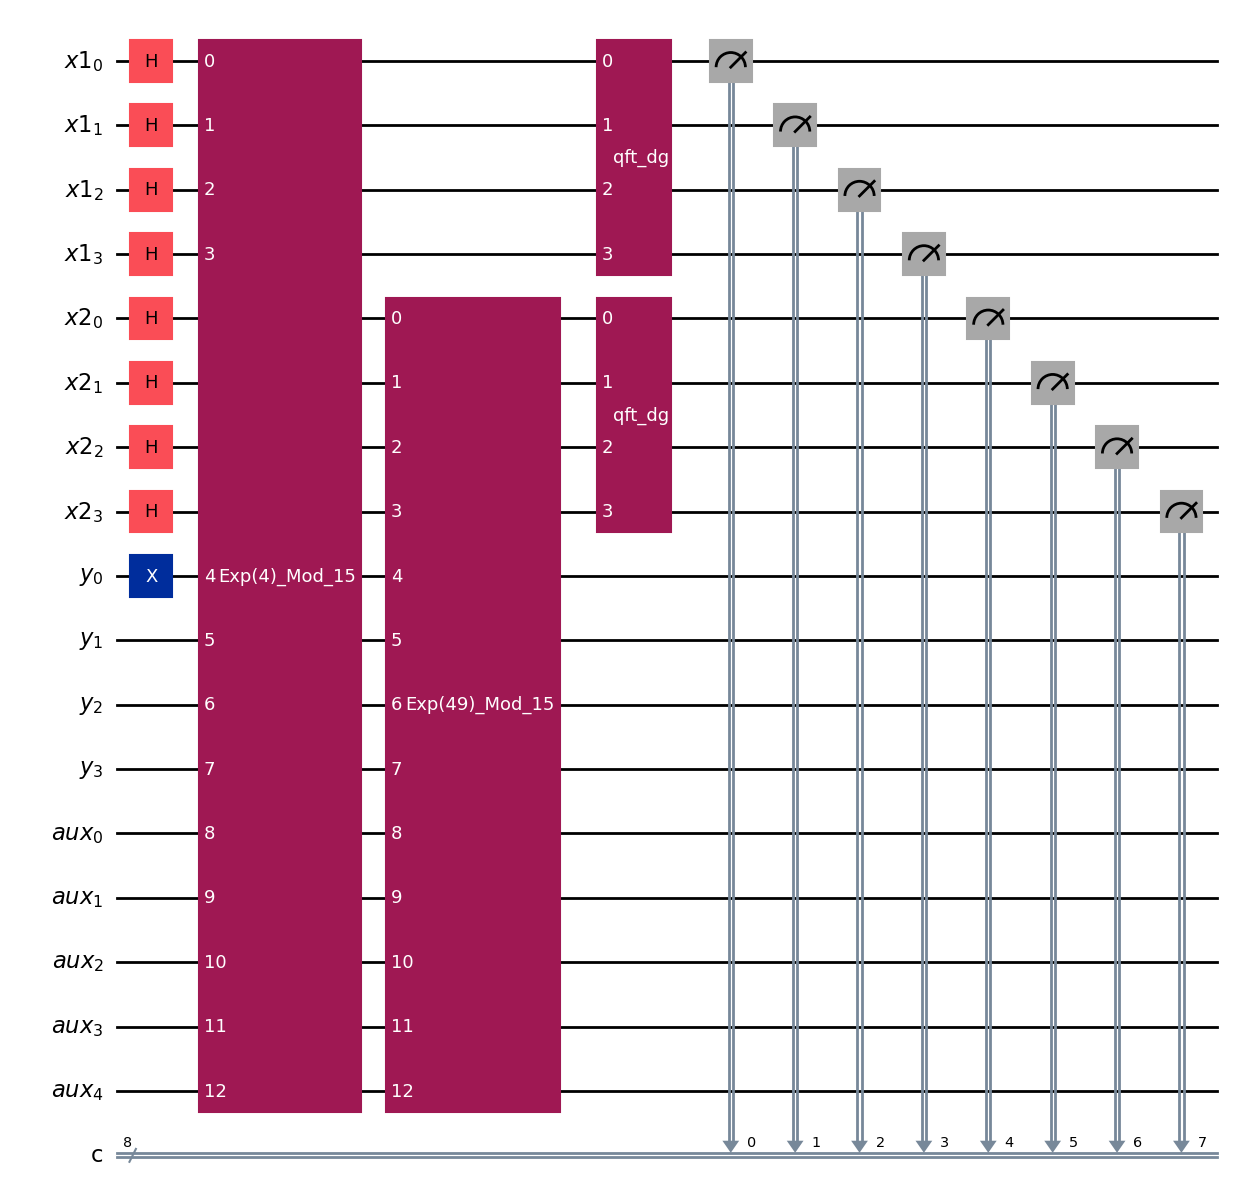

In [ ]:
# First tiny test.
# This is the safest one to run first.

qc_15, meta_15, counts_15, summary_15 = run_regev_simulation(
    N=15,
    shots=128,
    qd_mode="cover_2n",
    inverse_qft=True,
    draw=True
)

In [ ]:
toy_factor_from_regev_summary(summary_15, meta_15)

=== Toy classical post-processing ===
N: 15
d: 2
nd: 4
M: 16
bases: [4, 49]

Lucky factor found during base generation:
(3, 5)


(3, 5)

In [ ]:
# Show how the measured vectors would be passed to classical/lattice post-processing.

lattice_postprocessing_placeholder(summary_15, meta_15)

=== Classical post-processing placeholder ===
N: 15
d: 2
nd: 4
bases: [4, 49]

Sample vectors available for post-processing:
(8, 8) probability: 0.5390625
(0, 0) probability: 0.4609375

Next step:
Use these vectors as input to a lattice/number-theoretic reconstruction routine.


In [ ]:
# Second small test.
# If this is slow, lower shots to 64 or skip it.

qc_21, meta_21, counts_21, summary_21 = run_regev_simulation(
    N=21,
    shots=128,
    qd_mode="cover_2n",
    inverse_qft=True,
    draw=False
)

=== Regev-style simulation metadata ===
N: 21
n: 5
d: 3
nd: 4
M: 16
total_x_qubits: 12
estimated_total_qubits: 23
bases: [4, 25, 121]
lucky_factors: [(3, 7), (7, 3)]
inverse_qft: True
qd_mode: cover_2n

Circuit before transpilation:
qubits: 23
depth: 6
ops: OrderedDict({'h': 12, 'measure': 12, 'barrier': 3, 'qft_dg': 3, 'x': 1, 'Exp(4)_Mod_21': 1, 'Exp(25)_Mod_21': 1, 'Exp(121)_Mod_21': 1})

Circuit after transpilation:
qubits: 23
depth: 22586
ops: OrderedDict({'ccx': 15314, 'x': 6622, 'cx': 6216, 'cswap': 60, 'u3': 49, 'h': 24, 'cp': 18, 'measure': 12, 'swap': 6, 'barrier': 3})

Running simulator...

Top measured Regev vectors:
{'measured_vector': (0, 0, 0), 'count': 37, 'probability': 0.2890625, 'raw_bitstring': '000000000000'}
{'measured_vector': (11, 11, 5), 'count': 20, 'probability': 0.15625, 'raw_bitstring': '010110111011'}
{'measured_vector': (5, 5, 11), 'count': 11, 'probability': 0.0859375, 'raw_bitstring': '101101010101'}
{'measured_vector': (6, 5, 11), 'count': 7, 'probabil

In [ ]:
# Resource growth check.
# This does NOT run full simulations for big N.
# It only prints parameter sizes.

estimate_regev_resources([15, 21, 57, 2021])


N = 15
validation: {'valid': True, 'reason': 'N is an odd composite number.', 'factor': None, 'other': None}
parameters: {'N': 15, 'n': 4, 'd': 2, 'nd': 4, 'M': 16, 'total_x_qubits': 8, 'estimated_total_qubits': 17}

N = 21
validation: {'valid': True, 'reason': 'N is an odd composite number.', 'factor': None, 'other': None}
parameters: {'N': 21, 'n': 5, 'd': 3, 'nd': 4, 'M': 16, 'total_x_qubits': 12, 'estimated_total_qubits': 23}

N = 57
validation: {'valid': True, 'reason': 'N is an odd composite number.', 'factor': None, 'other': None}
parameters: {'N': 57, 'n': 6, 'd': 3, 'nd': 4, 'M': 16, 'total_x_qubits': 12, 'estimated_total_qubits': 25}

N = 2021
validation: {'valid': True, 'reason': 'N is an odd composite number.', 'factor': None, 'other': None}
parameters: {'N': 2021, 'n': 11, 'd': 4, 'nd': 6, 'M': 64, 'total_x_qubits': 24, 'estimated_total_qubits': 47}


We are very lucky! Here is p: 3 and q: 19


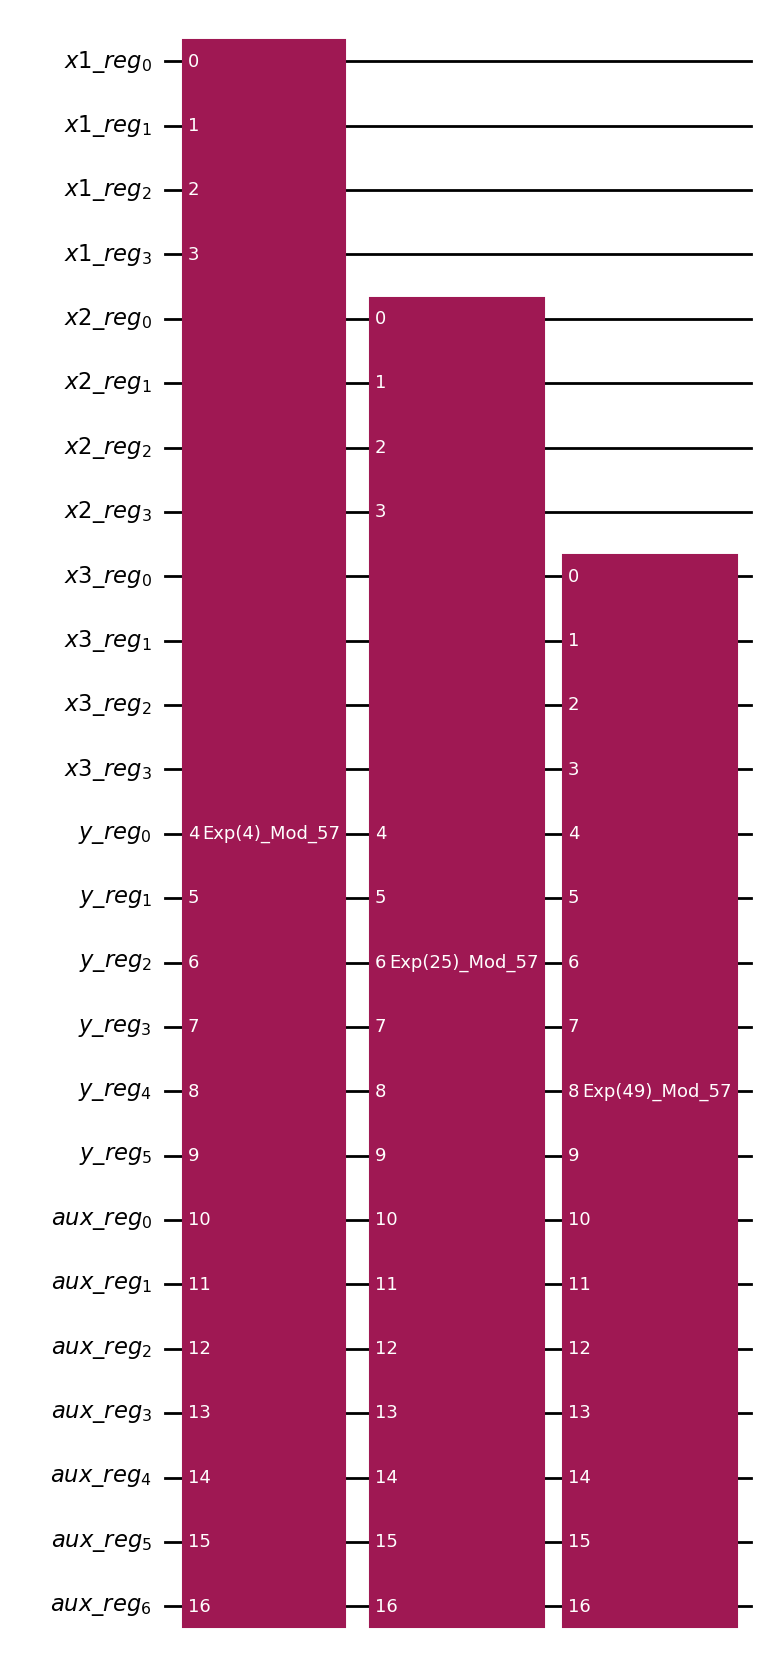

In [ ]:
import math
N = 57 # The number you want to factor

n = N.bit_length() # Number of bits N reqires
d = math.ceil(math.sqrt(n))
qd = math.floor((n/d)+d)

# Assuming N, n, qd are already defined from previous cells (N=57, n=6, qd=5)
# And 'a' is defined as [4, 25, 49]

# Define registers based on the requirements of modEXP(constant, N, n)
# The modular_exponentiation_gate expects registers with sizes defined by modular_exponentiation_gate_regs(n):
# 'x' register of size 2*n, 'y' of size n, 'aux' of size n+1
# Splitting the original 2*n (12) qubits for 'x' into three registers
x1 = QuantumRegister(2 * n // 3, name=f"x1_reg") # New x1, size 4 qubits
x2 = QuantumRegister(2 * n // 3, name=f"x2_reg") # New x2, size 4 qubits
x3 = QuantumRegister(2 * n // 3, name=f"x3_reg") # New x3, size 4 qubits

y = QuantumRegister(n, name=f"y_reg")     # Should be n = 6 qubits
aux = QuantumRegister(n + 1, name=f"aux_reg") # Should be n+1 = 7 qubits

# The circuit now includes the three new 'x' registers
qc = QuantumCircuit(x1, x2, x3, y, aux, name=f"ExpMod_Test")

# Use a suitable constant from 'a' (e.g., a[0]). We know a[0]=4 and gcd(4, 57)=1.
# The modular_exponentiation_gate takes (constant: int, N: int, n: int, qd: int)
a = generate_a(d, N)

qregs_all = qc.qregs

for i in range(d):
    qubits_to_pass = []
    qubits_to_pass += qregs_all[i]
    qubits_to_pass += qregs_all[-2]
    qubits_to_pass += qregs_all[-1]

    # Renamed variable to avoid name collision with the function
    # Adjusted qd to match the size of individual x registers (4 qubits)
    current_modexp_gate = modular_exponentiation_gate(a[i], N, n, 2 * n // 3)
    qc.append(
        current_modexp_gate,
        qubits_to_pass
    )
display(qc.draw('mpl',fold=-1, plot_barriers=False))

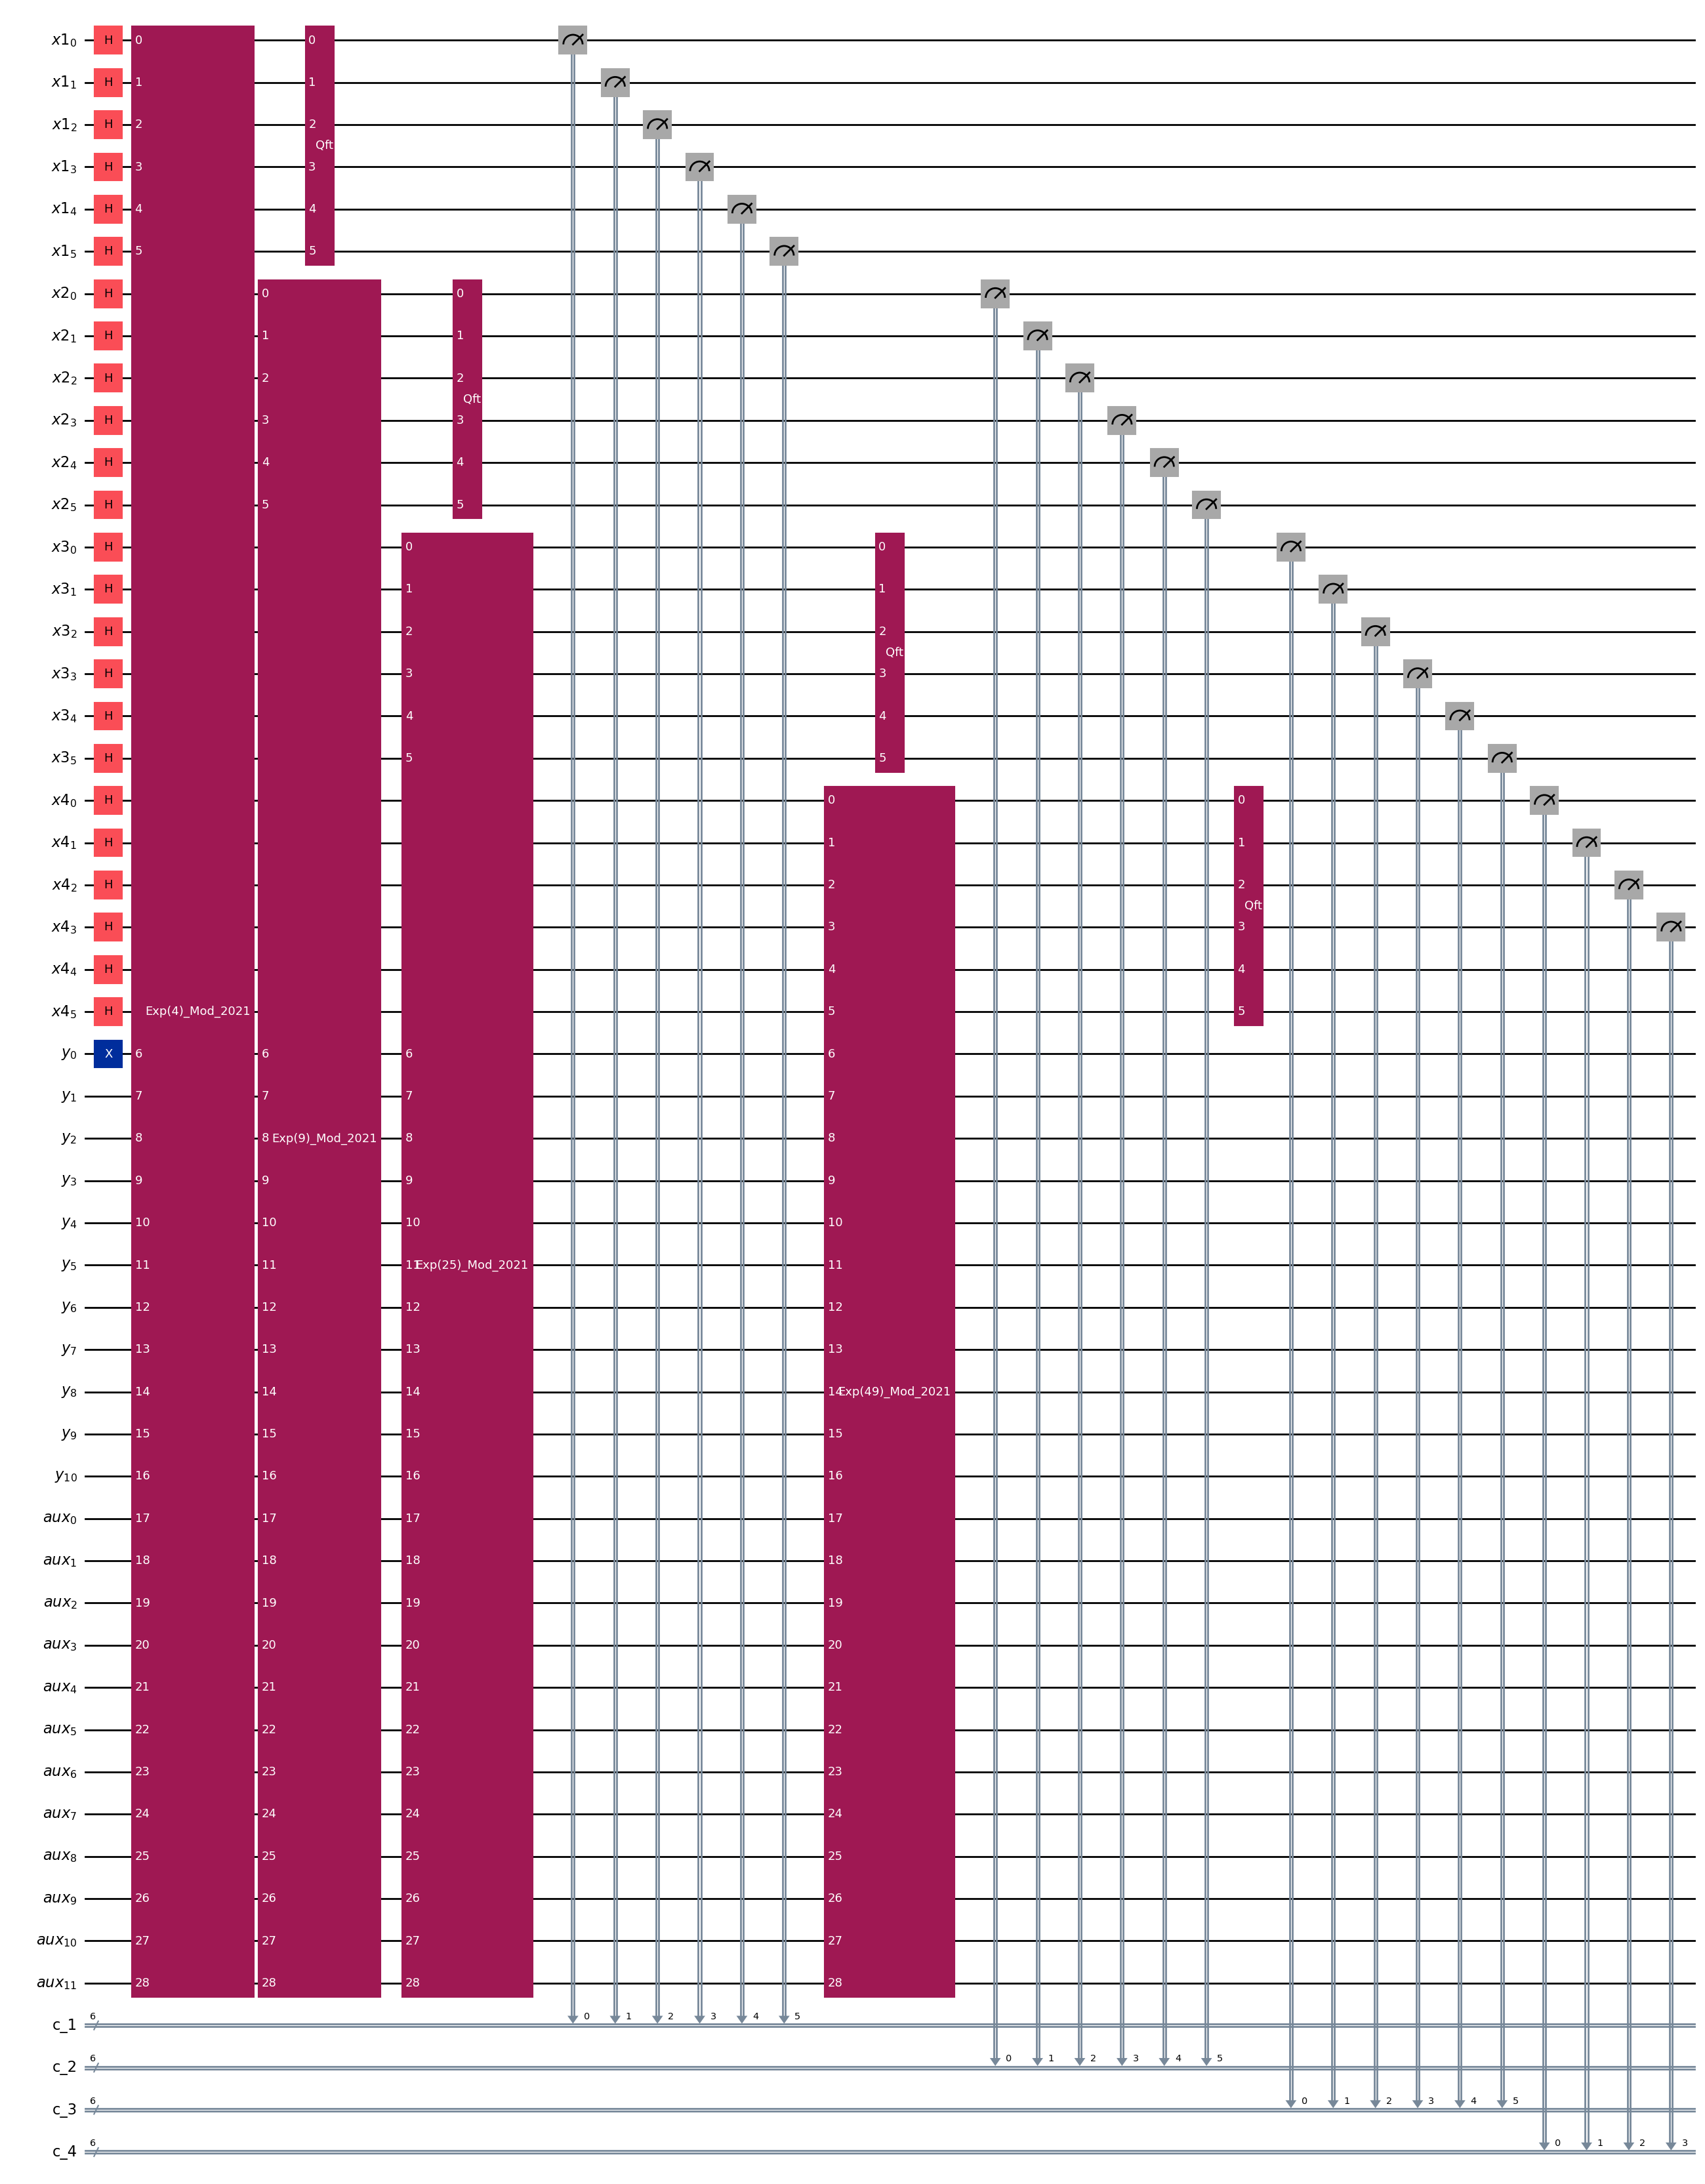

In [ ]:
N = 2021 # The number you want to factor

n = N.bit_length() # Number of bits N reqires
d = math.ceil(math.sqrt(n))
# qd = math.ceil((n/d)+d)
nd = math.ceil(2 * n / d)

xReg = list()
classical_registers = list()
# Initialize xReg with 2*n // d qubits, matching the gate's expectation for 'x' input
for i in range(d):
    xReg.append(QuantumRegister(nd, name=f"x{i+1}"))
    classical_registers.append(ClassicalRegister(nd, name=f"c_{i+1}"))

yReg = QuantumRegister(n, name=f"y")
auxReg = QuantumRegister(n + 1, name=f"aux")


qc = QuantumCircuit(*xReg, yReg, auxReg, *classical_registers, name=f"Regev N={N}")

# Apply Hadamard Gates to every Qubit of x1, x2, x3
for x in xReg:
    qc.h(x)

# Apply X Pauli to y[0]
qc.x(yReg[0])

# Generate an a value
a = generate_a(d, N)

qregs_all = qc.qregs

# Apply the Modular Exponential Gates
for i in range(d):
    qubits_to_pass = []
    qubits_to_pass += qregs_all[i]
    qubits_to_pass += qregs_all[-2]
    qubits_to_pass += qregs_all[-1]

    current_modexp_gate = modular_exponentiation_gate(a[i], N, n, nd)
    qc.append(
        current_modexp_gate,
        qubits_to_pass
    )

# Apply the d-Dim QFT
qft_regev = multidim_qft(d=d, n_per_reg=nd)
qc.compose(qft_regev, qubits=range(d * nd), inplace=True)

# Measure the output of the x registers
qc.measure(range(2*n), range(2*n))

display(qc.draw('mpl',fold=-1, plot_barriers=False))